In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

def get_generator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.BatchNorm1d(output_dim),
        nn.ReLU(inplace=True),
    )

class Generator(nn.Module):
    def __init__(self, z_dim, im_dim, hidden_dim=128):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            get_generator_block(z_dim, hidden_dim),
            get_generator_block(hidden_dim, hidden_dim * 2),
            get_generator_block(hidden_dim * 2, hidden_dim * 4),
            get_generator_block(hidden_dim * 4, hidden_dim * 8),
            nn.Linear(hidden_dim * 8, im_dim),
            nn.Sigmoid()
        )
    def forward(self, x): return self.gen(x)

def get_discriminator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.LeakyReLU(0.2, inplace=True)        
    )

class Discriminator(nn.Module):
    def __init__(self, im_dim, hidden_dim=128):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            get_discriminator_block(im_dim, hidden_dim * 4),
            get_discriminator_block(hidden_dim * 4, hidden_dim * 2),
            get_discriminator_block(hidden_dim * 2, hidden_dim),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x): return self.disc(x)

class CDSMOTE:
    def __init__(self, k_clusters=3, k_neighbors=5, random_state=42, verbose=True):
        self.k_clusters = k_clusters
        self.k_neighbors = k_neighbors
        self.random_state = random_state
        self.verbose = verbose
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def fit_resample(self, df, label_col="label_3", epochs=50, batch_size=512, lr=0.0001):
        id_cols = ["user_id", "course_id"]
        feature_cols = [c for c in df.columns if c not in id_cols + [label_col]]
        n_features = len(feature_cols)

        # ===== 0. CHUẨN HÓA =====
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df[feature_cols].values)
        y = df[label_col].astype(str).values

        classes, counts = np.unique(y, return_counts=True)
        majority_class = classes[np.argmax(counts)]

        if self.verbose:
            print("\nBắt đầu xử lý dữ liệu (CDSMOTE + GAN Refiner)")
            print(f"Lớp đa số: {majority_class} ({counts.max()} mẫu)")

        cluster_labels = np.empty(len(y), dtype=object)
        for cls in classes:
            idx = np.where(y == cls)[0]
            n_samples = len(idx)
            k = self.k_clusters if n_samples >= self.k_clusters else 1
            
            if self.verbose:
                print(f"Lớp {cls} được chia thành {k} cụm")

            kmeans = KMeans(n_clusters=k, init="random", n_init=10, random_state=self.random_state)
            labels = kmeans.fit_predict(X_scaled[idx])
            for i, lab in enumerate(labels):
                cluster_labels[idx[i]] = f"{cls}_c{lab}"

        unique_clusters = np.unique(cluster_labels)
        cluster_data = {uc: X_scaled[cluster_labels == uc] for uc in unique_clusters}
        
        new_samples_list = []
        max_count = df[label_col].value_counts().max()

        for cls in classes:
            if cls == majority_class: continue

            if self.verbose: print(f"\nĐang xử lý lớp {cls}")

            min_clusters = [uc for uc in unique_clusters if uc.startswith(f"{cls}_")]
            maj_clusters = [uc for uc in unique_clusters if uc.startswith(f"{majority_class}_")]
            n_clusters_min = len(min_clusters)
            if n_clusters_min == 0: continue
            
            target_size_per_cluster = max_count // n_clusters_min 

            for min_c in min_clusters:
                X_min = cluster_data[min_c]
                n_min = len(X_min)
                if n_min < 2: continue

                min_center = np.mean(X_min, axis=0).reshape(1, -1)
                maj_centers = np.array([np.mean(cluster_data[mc], axis=0) for mc in maj_clusters])
                distances = pairwise_distances(min_center, maj_centers)
                matched_maj_cluster = maj_clusters[np.argmin(distances)]
                
                X_maj = cluster_data[matched_maj_cluster]
                target_size = target_size_per_cluster

                if self.verbose:
                    print(f"  - Cụm: {min_c} ({n_min} mẫu) ghép với {matched_maj_cluster}")

                if target_size <= n_min: continue

                X_sub = np.vstack([X_min, X_maj])
                y_sub = np.array([0] * n_min + [1] * len(X_maj))
                k_eff = max(1, min(self.k_neighbors, n_min - 1))
                
                smoter = SMOTE(sampling_strategy={0: target_size}, k_neighbors=k_eff, random_state=self.random_state)
                
                try:
                    X_res, _ = smoter.fit_resample(X_sub, y_sub)
                    X_seed_samples = X_res[len(X_sub):] 
                    if len(X_seed_samples) == 0: continue

                    local_mms = MinMaxScaler()
                    X_real_norm = torch.FloatTensor(local_mms.fit_transform(X_min)).to(self.device)
                    X_seed_norm = torch.FloatTensor(local_mms.transform(X_seed_samples)).to(self.device)

                    gen = Generator(z_dim=n_features, im_dim=n_features).to(self.device)
                    disc = Discriminator(im_dim=n_features).to(self.device)
                    gen_opt = torch.optim.Adam(gen.parameters(), lr=lr)
                    disc_opt = torch.optim.Adam(disc.parameters(), lr=lr)
                    criterion = nn.BCEWithLogitsLoss()

                    dataloader = DataLoader(TensorDataset(X_real_norm), batch_size=batch_size, shuffle=True)

                    gen.train(); disc.train()
                    for epoch in range(epochs):
                        for real_batch in dataloader:
                            real = real_batch[0]; curr_bs = len(real)
                            idx = torch.randint(0, len(X_seed_norm), (curr_bs,))
                            batch_seeds = X_seed_norm[idx]

                            disc_opt.zero_grad()
                            fake = gen(batch_seeds)
                            loss_d = (criterion(disc(real), torch.ones(curr_bs, 1).to(self.device)) + 
                                      criterion(disc(fake.detach()), torch.zeros(curr_bs, 1).to(self.device))) / 2
                            loss_d.backward(); disc_opt.step()

                            gen_opt.zero_grad()
                            loss_g = criterion(disc(fake), torch.ones(curr_bs, 1).to(self.device))
                            loss_g.backward(); gen_opt.step()

                    gen.eval()
                    with torch.no_grad():
                        refined_norm = gen(X_seed_norm).cpu().numpy()
                    
                    X_syn_scaled = local_mms.inverse_transform(refined_norm)
                    X_syn_original = scaler.inverse_transform(X_syn_scaled)

                    df_syn = pd.DataFrame(X_syn_original, columns=feature_cols)
                    df_syn[label_col] = cls

                    for col in id_cols:
                        if col in df.columns:
                            original_ids = df[df[label_col].astype(str) == cls][col].values
                            df_syn[col] = np.random.choice(original_ids, size=len(df_syn))

                    new_samples_list.append(df_syn)
                    if self.verbose: print(f"    GAN đã tinh chỉnh xong {len(df_syn)} mẫu")

                except Exception as e:
                    if self.verbose: print(f"    Lỗi tại cụm {min_c}: {e}")

        # ===== 3. GHÉP DỮ LIỆU =====
        if new_samples_list:
            df_final = pd.concat([df] + new_samples_list, axis=0, ignore_index=True)
            try:
                df_final[label_col] = df_final[label_col].astype(float).astype(int)
            except: pass
            
            if self.verbose:
                print(f"\nHoàn tất. Tổng số mẫu sau cùng: {len(df_final)}")
            return df_final.sample(frac=1, random_state=self.random_state).reset_index(drop=True)
        
        return df.copy()

# Median imputation CDSMOTE

In [2]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Median/Median/train_median.parquet"
LABEL_COL = "label_3"

df_median = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_median.shape}")
df_median

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1,140538,475,114,2020,10,30,76,2,0.0,58,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
2,125447,750,170,2020,2,12,69,2,0.0,56,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
3,24957,17,151,2020,2,16,138,2,2.0,7,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
4,977326,468,173,2020,10,30,140,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0


In [3]:
# Chạy cdsmote
print(f"Phân bố label trước CDSMOTE-GAN:")
print(df_median[LABEL_COL].value_counts().sort_index())

cdsmote = CDSMOTE(verbose=True)
df_balanced = cdsmote.fit_resample(df_median, label_col="label_3")

print(f"\nPhân bố label sau CDSMOTE-GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước CDSMOTE-GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Bắt đầu xử lý dữ liệu (CDSMOTE + GAN Refiner)
Lớp đa số: 2 (1852997 mẫu)
Lớp 0 được chia thành 3 cụm
Lớp 1 được chia thành 3 cụm
Lớp 2 được chia thành 3 cụm

Đang xử lý lớp 0
  - Cụm: 0_c0 (259 mẫu) ghép với 2_c2
    GAN đã tinh chỉnh xong 617406 mẫu
  - Cụm: 0_c1 (1186 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 616479 mẫu
  - Cụm: 0_c2 (338 mẫu) ghép với 2_c0
    GAN đã tinh chỉnh xong 617327 mẫu

Đang xử lý lớp 1
  - Cụm: 1_c0 (546 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 617119 mẫu
  - Cụm: 1_c1 (3905 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 613760 mẫu
  - Cụm: 1_c2 (388 mẫu) ghép với 2_c2
    GAN đã tinh chỉnh xong 617277 mẫu

Hoàn tất. Tổng số mẫu sau cùng: 5558987

Phân bố label sau CDSMOTE-GAN:
label_3
0    1852995
1    1852995
2    1852997
Name: count, dtype: int64


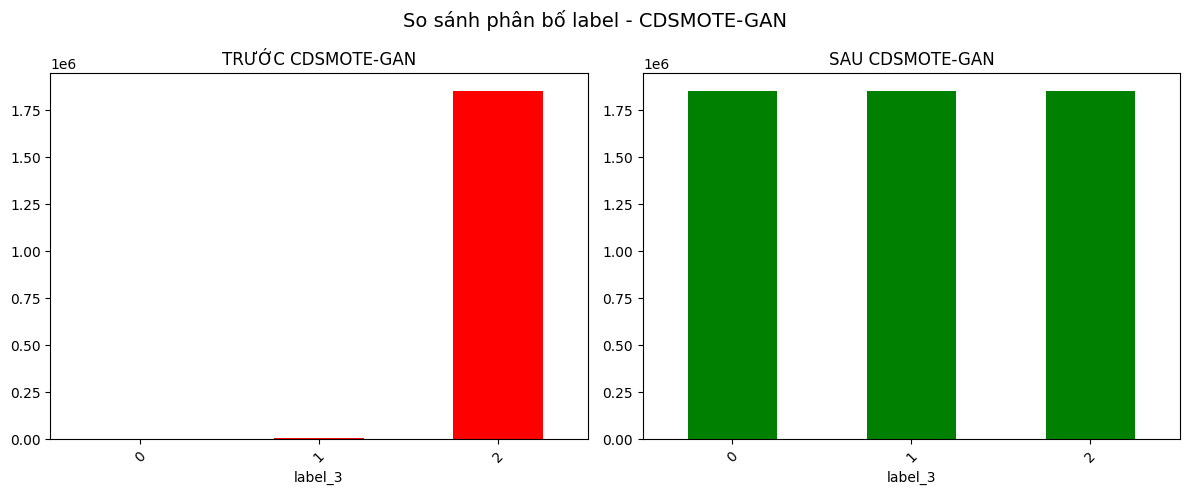

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_median[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC CDSMOTE-GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU CDSMOTE-GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - CDSMOTE-GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
df_balanced.to_parquet("train_median_cdsmote_gan.parquet", index=False)

# Mean imputation CDSMOTE

In [6]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Mean/Mean/train_mean.parquet"
LABEL_COL = "label_3"

df_mean = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_mean.shape}")
df_mean

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1,140538,475,114,2020,10,30,76,2,0.0,58,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
2,125447,750,170,2020,2,12,69,2,0.0,56,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
3,24957,17,151,2020,2,16,138,2,2.0,7,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
4,977326,468,173,2020,10,30,140,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781


In [7]:
# Chạy cdsmote
print(f"Phân bố label trước CDSMOTE-GAN:")
print(df_mean[LABEL_COL].value_counts().sort_index())

cdsmote = CDSMOTE(verbose=True)
df_balanced = cdsmote.fit_resample(df_mean, label_col="label_3")

print(f"\nPhân bố label sau CDSMOTE-GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước CDSMOTE-GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Bắt đầu xử lý dữ liệu (CDSMOTE + GAN Refiner)
Lớp đa số: 2 (1852997 mẫu)
Lớp 0 được chia thành 3 cụm
Lớp 1 được chia thành 3 cụm
Lớp 2 được chia thành 3 cụm

Đang xử lý lớp 0
  - Cụm: 0_c0 (351 mẫu) ghép với 2_c0
    GAN đã tinh chỉnh xong 617314 mẫu
  - Cụm: 0_c1 (1200 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 616465 mẫu
  - Cụm: 0_c2 (232 mẫu) ghép với 2_c0
    GAN đã tinh chỉnh xong 617433 mẫu

Đang xử lý lớp 1
  - Cụm: 1_c0 (932 mẫu) ghép với 2_c0
    GAN đã tinh chỉnh xong 616733 mẫu
  - Cụm: 1_c1 (345 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 617320 mẫu
  - Cụm: 1_c2 (3562 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 614103 mẫu

Hoàn tất. Tổng số mẫu sau cùng: 5558987

Phân bố label sau CDSMOTE-GAN:
label_3
0    1852995
1    1852995
2    1852997
Name: count, dtype: int64


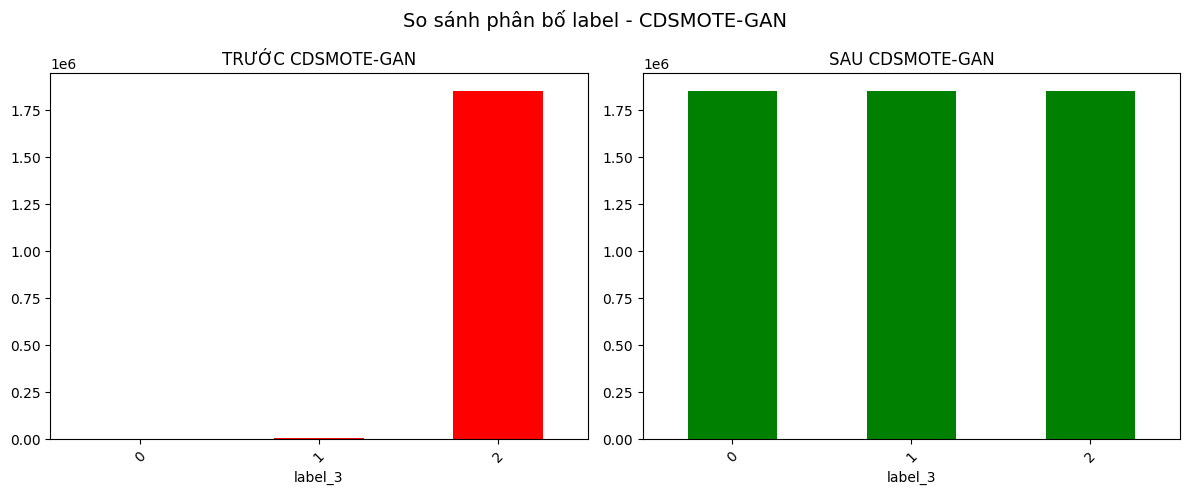

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_mean[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC CDSMOTE-GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU CDSMOTE-GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - CDSMOTE-GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
df_balanced.to_parquet("train_mean_cdsmote_gan.parquet", index=False)

# Extra_trees imputation CDSMOTE

In [10]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Extra_trees/Extra_trees/train_extra.parquet"
LABEL_COL = "label_3"

df_Extra_trees = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_Extra_trees.shape}")
df_Extra_trees

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176.0,2020.0,2.0,6.0,170.0,2,2.0,6.0,...,28.345097,75.224105,2.239722,0.651001,31.967399,0.010466,0.119216,0.749036,0.123232,0.743935
1,140538,475,114.0,2020.0,10.0,30.0,76.0,2,0.0,58.0,...,24.601815,77.347451,2.418864,0.657834,24.714212,0.006163,0.146233,0.768704,0.091260,0.712458
2,125447,750,170.0,2020.0,2.0,12.0,69.0,2,0.0,56.0,...,25.038668,67.816256,1.746079,0.684022,26.336268,0.004388,0.103833,0.770995,0.114709,0.704242
3,24957,17,151.0,2020.0,2.0,16.0,138.0,2,2.0,7.0,...,21.832723,61.084016,2.188559,0.651001,24.026333,0.007815,0.110005,0.761642,0.127080,0.719493
4,977326,468,173.0,2020.0,10.0,30.0,140.0,2,2.0,2.0,...,21.870573,68.990436,2.088095,0.657834,25.265029,0.003142,0.139406,0.761305,0.099424,0.738092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91.0,2019.0,12.0,31.0,52.0,2,0.0,49.0,...,48.100983,155.905533,2.164014,0.679425,25.602336,0.004796,0.163354,0.724069,0.105012,0.749764
1859615,106770,862,121.0,2020.0,9.0,1.0,31.0,2,0.0,60.0,...,40.613763,87.318300,2.086876,0.657834,31.689427,0.004874,0.097344,0.749513,0.159769,0.790002
1859616,258729,833,93.0,2020.0,4.0,13.0,91.0,2,2.0,2.0,...,21.292247,49.104277,1.740292,0.656641,27.509743,0.001563,0.099459,0.785990,0.114119,0.645251
1859617,969906,616,121.0,2020.0,9.0,1.0,37.0,2,1.0,3.0,...,36.010158,101.582165,1.676263,0.658539,25.701191,0.001337,0.098596,0.737834,0.163638,0.803611


In [11]:
# Chạy cdsmote
print(f"Phân bố label trước CDSMOTE-GAN:")
print(df_Extra_trees[LABEL_COL].value_counts().sort_index())

cdsmote = CDSMOTE(verbose=True)
df_balanced = cdsmote.fit_resample(df_Extra_trees, label_col="label_3")

print(f"\nPhân bố label sau CDSMOTE-GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước CDSMOTE-GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Bắt đầu xử lý dữ liệu (CDSMOTE + GAN Refiner)
Lớp đa số: 2 (1852997 mẫu)
Lớp 0 được chia thành 3 cụm
Lớp 1 được chia thành 3 cụm
Lớp 2 được chia thành 3 cụm

Đang xử lý lớp 0
  - Cụm: 0_c0 (1343 mẫu) ghép với 2_c2
    GAN đã tinh chỉnh xong 616322 mẫu
  - Cụm: 0_c1 (249 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 617416 mẫu
  - Cụm: 0_c2 (191 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 617474 mẫu

Đang xử lý lớp 1
  - Cụm: 1_c0 (2108 mẫu) ghép với 2_c2
    GAN đã tinh chỉnh xong 615557 mẫu
  - Cụm: 1_c1 (339 mẫu) ghép với 2_c0
    GAN đã tinh chỉnh xong 617326 mẫu
  - Cụm: 1_c2 (2392 mẫu) ghép với 2_c1
    GAN đã tinh chỉnh xong 615273 mẫu

Hoàn tất. Tổng số mẫu sau cùng: 5558987

Phân bố label sau CDSMOTE-GAN:
label_3
0    1852995
1    1852995
2    1852997
Name: count, dtype: int64


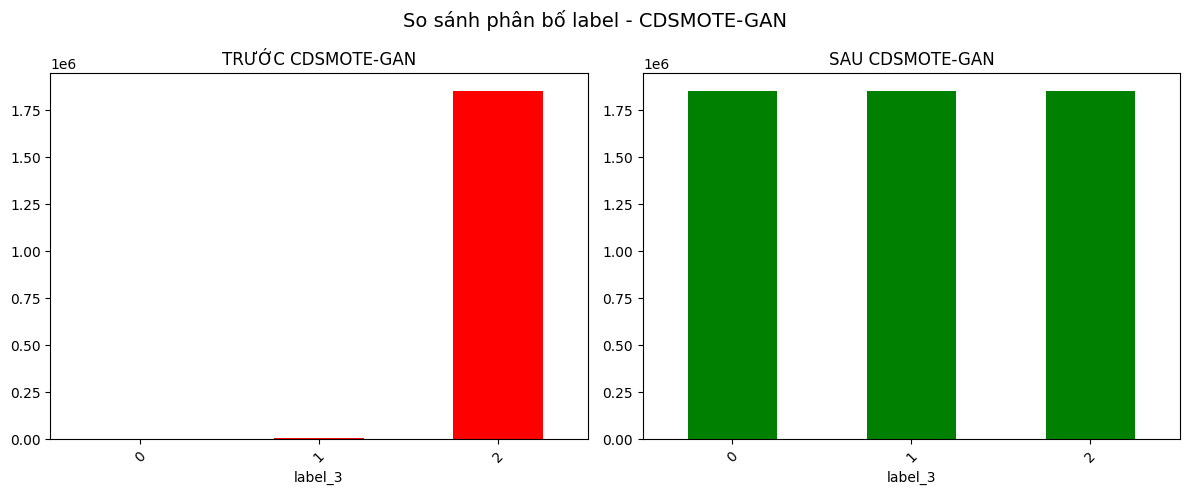

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_Extra_trees[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC CDSMOTE-GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU CDSMOTE-GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - CDSMOTE-GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
df_balanced.to_parquet("train_Extra_trees_cdsmote_gan.parquet", index=False)